In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)


In [14]:
df = pd.read_csv("A:/Forest_Fire_Smoke_Dataset.csv")
df.head(10)


,mean_red,mean_green,mean_blue,red_blue_ratio,intensity_std,edge_density,smoke_whiteness,haze_index,hot_pixel_fraction,local_contrast,fire_label
0,0.523653,0.299277,0.265874,1.962171,0.068402,0.223412,0.472959,0.333490,0.158385,0.524992,0
1,0.724041,0.394328,0.453850,1.591822,0.290540,0.345590,0.384785,0.404510,0.222511,0.100019,1
2,0.732028,0.492876,0.555428,1.315584,0.264537,0.330369,0.705461,0.625930,0.359686,0.701875,1
3,0.589471,0.527046,0.536978,1.095716,0.136997,0.458620,0.361735,0.367842,0.073597,0.777261,0
4,0.385249,0.669345,0.473443,0.812004,0.262034,0.295832,0.294756,0.702075,0.221406,0.610500,0
5,0.557389,0.545570,0.542242,1.026042,0.056164,0.124524,0.415403,0.197970,0.119923,0.496452,0
6,0.254158,0.444321,0.405338,0.625484,0.016963,0.364687,0.520745,0.397705,0.078839,0.417085,0
7,0.667207,0.360956,0.462810,1.438533,0.244155,0.513806,0.661080,0.567832,0.264203,0.519440,1
8,0.233155,0.393571,0.331922,0.700328,0.192625,0.371238,0.318251,0.577081,0.011882,0.700373,0
9,0.699038,0.390730,0.429227,1.624815,0.145507,0.221234,0.407653,0.399643,0.465004,0.582727,1


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mean_red            3000 non-null   float64
 1   mean_green          3000 non-null   float64
 2   mean_blue           3000 non-null   float64
 3   red_blue_ratio      3000 non-null   float64
 4   intensity_std       3000 non-null   float64
 5   edge_density        3000 non-null   float64
 6   smoke_whiteness     3000 non-null   float64
 7   haze_index          3000 non-null   float64
 8   hot_pixel_fraction  3000 non-null   float64
 9   local_contrast      3000 non-null   float64
 10  fire_label          3000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 257.9 KB


In [16]:
df.describe()


,mean_red,mean_green,mean_blue,red_blue_ratio,intensity_std,edge_density,smoke_whiteness,haze_index,hot_pixel_fraction,local_contrast,fire_label
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.518938,0.448972,0.402150,1.389752,0.177488,0.298231,0.451353,0.448115,0.172722,0.500876,0.353000
std,0.156641,0.096770,0.101042,0.645881,0.076539,0.100044,0.128224,0.151640,0.148877,0.152486,0.477982
min,0.007396,0.057760,0.067889,0.023168,-0.050154,-0.065509,0.054665,-0.079923,0.000024,-0.002723,0.000000
25%,0.406602,0.383908,0.334892,0.967969,0.124140,0.228201,0.362181,0.347613,0.056877,0.398500,0.000000
50%,0.512438,0.449158,0.401911,1.283325,0.171093,0.297301,0.443042,0.447587,0.130256,0.502897,0.000000
75%,0.626587,0.513919,0.469644,1.656747,0.223977,0.366417,0.533889,0.553470,0.246473,0.602656,1.000000
max,1.039171,0.787777,0.742891,10.432023,0.440258,0.661135,0.904803,0.952231,0.924168,1.010847,1.000000


Task 1: Data Understanding
Feature Relevance Explanation:
Spectral features capture color variations caused by fire and smoke.
Intensity features highlight bright regions typical of flames.
Texture features capture irregular patterns introduced by smoke clouds, helping differentiate them from forest backgrounds.

In [18]:
df.columns


Index(['mean_red', 'mean_green', 'mean_blue', 'red_blue_ratio',
       'intensity_std', 'edge_density', 'smoke_whiteness', 'haze_index',
       'hot_pixel_fraction', 'local_contrast', 'fire_label'],
      dtype='object')

In [20]:
X = df.drop("fire_label", axis=1)
y = df["fire_label"]


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [22]:
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print("Baseline Model Performance")
print(classification_report(y_test, y_pred_base))


Baseline Model Performance
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       388
           1       0.95      0.86      0.90       212

    accuracy                           0.93       600
   macro avg       0.94      0.92      0.93       600
weighted avg       0.93      0.93      0.93       600



Task 2: Machine Learning Model

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       388
           1       0.94      0.84      0.89       212

    accuracy                           0.93       600
   macro avg       0.93      0.91      0.92       600
weighted avg       0.93      0.93      0.92       600

Confusion Matrix
[[377  11]
 [ 34 178]]
ROC-AUC Score: 0.9662030733320365


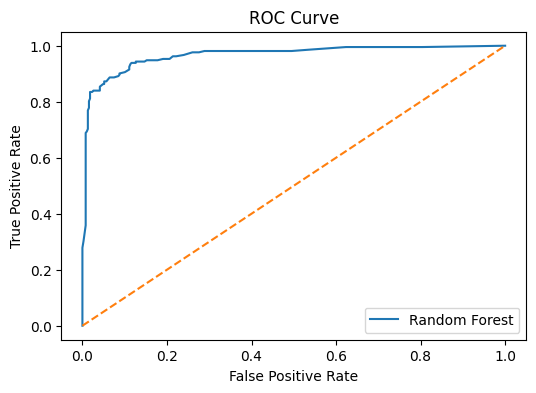

In [26]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred))

print("Confusion Matrix")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Task 3: Spatial Risk Analysis & Visualization

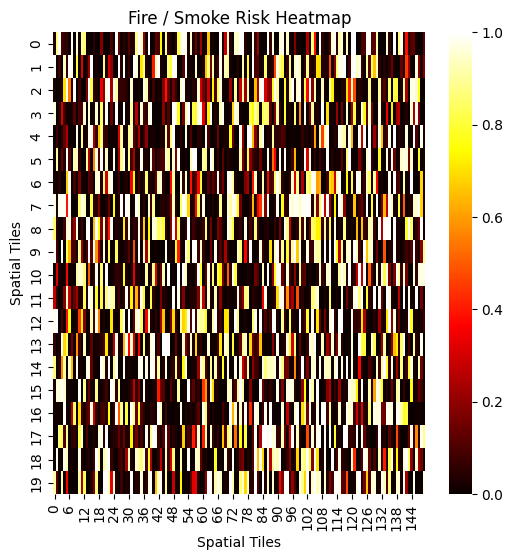

In [28]:

risk_grid = df["risk_score"].values.reshape(20, -1)

plt.figure(figsize=(6,6))
sns.heatmap(risk_grid, cmap="hot", cbar=True)
plt.title("Fire / Smoke Risk Heatmap")
plt.xlabel("Spatial Tiles")
plt.ylabel("Spatial Tiles")
plt.show()




Task 4: Drone & Disaster Response Interpretation


- High-risk areas should be monitored continuously using drones.
- Medium-risk regions require periodic scanning.
- Low-risk zones need minimal surveillance.
- Thermal and RGB cameras can enhance early fire detection.

Task 5: Reflection

### Limitations
- Dataset uses pre-extracted features instead of raw images.
- Weather and lighting conditions may cause false positives.

### Future Improvements
- Use CNNs on raw aerial imagery.
- Incorporate temporal (time-series) data.
- Combine satellite and drone imagery for better coverage.



Short technical interpretation report
1. Introduction

Forest fires pose a serious threat to ecosystems, wildlife, and human settlements, making early detection critical for disaster management. This project focuses on detecting forest fire and smoke regions using machine learning techniques applied to feature-level aerial imagery data. By analyzing spectral, intensity, and texture-based features extracted from aerial tiles, the system aims to identify high-risk regions efficiently. The proposed approach supports drone-based monitoring systems by enabling faster and more targeted response strategies.

2. Methodology
   
Dataset

The dataset consists of tile-level features extracted from aerial imagery. Each row represents a spatial tile, and the features capture color, brightness, and texture characteristics relevant to fire and smoke detection. The target variable indicates the presence or absence of fire or smoke.

Feature-Based Machine Learning

Instead of using raw images, the project employs a feature-based supervised learning approach. This reduces computational complexity while still capturing important visual indicators of fire and smoke.

Model Selection

Logistic Regression was used as a baseline model, while a Random Forest classifier was selected as the final model due to its ability to handle non-linear relationships and perform robustly on tabular data.

3. Results & Interpretation

The Random Forest model achieved strong performance on the test dataset:
Accuracy: 93%
ROC-AUC Score: 0.96

The confusion matrix showed that most fire and non-fire tiles were correctly classified. The model demonstrated high precision for fire detection, reducing false alarms, while maintaining strong recall to minimize missed fire events. The high ROC-AUC score indicates excellent separability between fire/smoke and non-fire regions, making the model reliable for real-world monitoring scenarios.

4. Drone & Disaster Response Interpretation

Based on the predicted fire-risk scores, drone deployment can be prioritized effectively. High-risk regions should be monitored continuously using drones equipped with thermal and RGB cameras to enable early fire detection. Medium-risk areas can be scanned periodically to track risk escalation, while low-risk zones require minimal surveillance. This risk-based deployment strategy optimizes resource utilization and reduces emergency response time.

5. Reflection
   
Limitations:
The dataset relies on pre-extracted features rather than raw imagery, limiting the model’s ability to learn complex spatial patterns. Environmental factors such as fog, clouds, or lighting variations may also cause occasional false positives. Additionally, spatial relationships between neighboring tiles are not explicitly considered.

Future Improvements
Future work can involve training Convolutional Neural Networks (CNNs) on raw aerial imagery to capture richer spatial features. Incorporating temporal data from repeated drone flights can improve detection reliability over time. Integrating geospatial information and combining satellite imagery with drone data can further enhance large-scale fire monitoring and response.